In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 一般用于batch下一个维度
input = torch.randn(2,4)
m = nn.BatchNorm1d(4)
output = m(input)
print(output)   
print(output.mean(0))  # Mean across the batch dimension
print(output.std(dim=0, unbiased=False))   # Standard deviation across the batch dimension

tensor([[ 1.0000,  1.0000, -1.0000,  1.0000],
        [-1.0000, -1.0000,  1.0000, -1.0000]],
       grad_fn=<NativeBatchNormBackward0>)
tensor([ 0.0000e+00,  0.0000e+00, -5.9605e-08,  2.9802e-08],
       grad_fn=<MeanBackward1>)
tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<StdBackward0>)


In [2]:
input = torch.randn(2,2,2,3)    # [N, C, H, W] 
m = nn.BatchNorm2d(2)
output = m(input)
print(output)

first_channel = output[:, 0, :, :].reshape(-1)
print(first_channel)  # First channel of the output
print(first_channel.mean(0))  # Mean across the batch dimension
print(first_channel.std(dim=0, unbiased=False))  # Standard deviation across the batch dimension

tensor([[[[ 0.2995,  0.5540, -1.1156],
          [-0.8215,  1.2803, -0.0683]],

         [[-1.3623,  0.4609,  0.8693],
          [-0.8161, -1.9121,  0.7400]]],


        [[[ 0.5752, -0.4159,  1.9035],
          [-1.4847,  0.5009, -1.2074]],

         [[ 1.4732, -0.6994,  1.1397],
          [-0.2881, -0.1084,  0.5031]]]], grad_fn=<NativeBatchNormBackward0>)
tensor([ 0.2995,  0.5540, -1.1156, -0.8215,  1.2803, -0.0683,  0.5752, -0.4159,
         1.9035, -1.4847,  0.5009, -1.2074], grad_fn=<UnsafeViewBackward0>)
tensor(0., grad_fn=<MeanBackward1>)
tensor(1.0000, grad_fn=<StdBackward0>)


In [3]:
# 均值和标准差是在最后 D 个维度上计算的
batch, sentence_length, embedding_dim = 20, 5, 10
embedding = torch.randn(batch, sentence_length, embedding_dim)
layer_norm = nn.LayerNorm(embedding_dim)
# Activate module
output = layer_norm(embedding)

print(output[0,0,:].mean(dim=0))
print(output[0,0,:].std(dim=0, unbiased=False))  # Standard deviation across the embedding dimension

tensor(8.9407e-09, grad_fn=<MeanBackward1>)
tensor(1.0000, grad_fn=<StdBackward0>)


In [4]:
N, C, H, W = 20, 5, 10, 10
input = torch.randn(N, C, H, W)
# Normalize over the last three dimensions (i.e. the channel and spatial dimensions)
# as shown in the image below
layer_norm = nn.LayerNorm([C, H, W])
output = layer_norm(input)

print(output[0,:].mean())
print(output[0,:].std(unbiased=False))

print(output.mean(dim=(1, 2, 3)))  # Mean across the batch and spatial dimensions

tensor(3.0994e-09, grad_fn=<MeanBackward0>)
tensor(1.0000, grad_fn=<StdBackward0>)
tensor([ 3.0994e-09, -2.2888e-08, -8.5831e-09, -1.4782e-08, -1.5736e-08,
        -1.7166e-08,  5.7220e-09,  6.6757e-09,  1.3351e-08, -1.4305e-08,
        -5.7220e-09, -1.8120e-08,  5.7220e-09, -6.1989e-09, -1.3351e-08,
         1.1683e-08,  3.8147e-09, -1.8358e-08,  3.8147e-09,  7.1526e-10],
       grad_fn=<MeanBackward1>)


In [5]:
# torch2.7才有
rms_norm = nn.RMSNorm([2, 3])
input = torch.randn(2, 2, 3)
rms_norm(input)

AttributeError: module 'torch.nn' has no attribute 'RMSNorm'

layernorm VS RMSnorm

In [6]:
bs, seq_len, embedding_dim = 20, 5, 10
x = torch.randn(bs, seq_len, embedding_dim)
layer_norm = nn.LayerNorm(embedding_dim)
output = layer_norm(x)
print(output[2, 1, :].mean(dim=0))
print(output[0, 3, :].std(dim=0, unbiased=False))

tensor(5.0664e-08, grad_fn=<MeanBackward1>)
tensor(1.0000, grad_fn=<StdBackward0>)


In [7]:
class RMSNorm(torch.nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        output = self._norm(x.float()).type_as(x)
        return output * self.weight

In [8]:
rms_norm = RMSNorm(embedding_dim)
x_rms = rms_norm(x)
print(x.pow(2).mean(-1, keepdim=True).shape)
print(x[0, 0, :])
print(x_rms[0, 0, :])

torch.Size([20, 5, 1])
tensor([ 1.5395,  1.8711,  0.3856, -1.0405, -0.5494, -0.9615, -0.0554, -0.4598,
         0.7332,  0.7436])
tensor([ 1.5685,  1.9063,  0.3928, -1.0601, -0.5597, -0.9796, -0.0565, -0.4684,
         0.7471,  0.7576], grad_fn=<SliceBackward0>)


In [9]:
x[0, 0, :] / torch.sqrt(torch.sum(x[0, 0, :].pow(2)) / embedding_dim)

tensor([ 1.5685,  1.9063,  0.3928, -1.0601, -0.5597, -0.9796, -0.0565, -0.4684,
         0.7471,  0.7576])

rms归一化后的范数

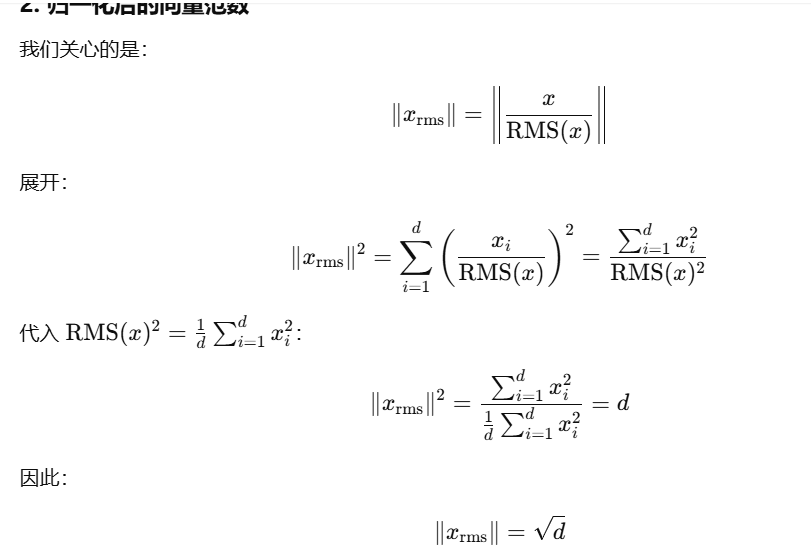

In [10]:
# 根号n 根号10 = 3.16
print(torch.norm(x_rms[0, 0, :]))
import numpy as np
print(np.sqrt(embedding_dim))

tensor(3.1623, grad_fn=<LinalgVectorNormBackward0>)
3.1622776601683795
